# 📋 SOURCE ANALYSIS — Kiểm tra & Đối chiếu Dữ liệu

**Mục đích:** Kiểm tra từng con số, schema, và thống kê trong `SOURCE_ANALYSIS_DOCUMENT_v2.md` bằng code thực tế.  
**Dataset:** Amazon Reviews 2023 — Electronics (McAuley Lab, UCSD)  
**Phương pháp:** HuggingFace streaming → sample / count → đối chiếu với tài liệu.

---

| # | Mục kiểm tra | Mục trong tài liệu |
|---|---|---|
| 1 | Quy mô dataset (Users, Items, Ratings) | §3.1 |
| 2 | Schema Review file | §3.2 |
| 3 | Schema Metadata file | §3.3 |
| 4 | Khoảng thời gian dữ liệu | §3.1 |
| 5 | Phân bố rating | §3.1 |
| 6 | Ước lượng token counts (Review + Meta) | §3.1 |
| 7 | Kiểm tra Infrastructure (Spark, MinIO, Docker) | Header table |
| 8 | Khảo sát verified_purchase, helpful_vote, text | §3.2 |
| 9 | Phân bố Price, Brand, Rating Number (Metadata) | §3.3 |
| 10 | Phân bố Reviews theo thời gian | §3.1 |
| 11 | Đánh giá chất lượng dữ liệu (Null, Duplicates) | Data Quality |
| 12 | Tổng hợp đối chiếu | Summary |

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 0: Setup & Imports
# ═══════════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
from datetime import datetime
import time, sys, os

# Thêm project root vào path
sys.path.insert(0, os.path.abspath('..'))

# Hằng số từ tài liệu (SOURCE_ANALYSIS_DOCUMENT_v2.md)
DOC_CLAIMS = {
    'num_users':        18_300_000,
    'num_items':         1_600_000,
    'num_ratings':      43_900_000,
    'review_tokens':  2_700_000_000,
    'meta_tokens':    1_700_000_000,
    'time_start':       'May 1996',
    'time_end':         'Sep 2023',
    'format':           'JSONL.gz → Parquet',
    'spark_version':    '3.5.1',
    'pyspark_version':  '3.5.0',
    'num_containers':   5,
    'buckets':          ['electronics-bronze', 'electronics-silver', 'electronics-gold'],
}

print("✅ Setup complete")
print(f"Python {sys.version}")
print(f"Pandas {pd.__version__}, NumPy {np.__version__}")

✅ Setup complete
Python 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
Pandas 2.1.4, NumPy 1.26.2


## 1️⃣ Kiểm tra quy mô dataset (§3.1)

**Tài liệu ghi:**
- `#User = 18,300,000` | `#Item = 1,600,000` | `#Rating = 43,900,000`

**Phương pháp:** Load dataset info từ HuggingFace (không cần download toàn bộ).

In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 1: Đếm tổng số ratings từ dataset info
# ═══════════════════════════════════════════════════════════════
from datasets import load_dataset_builder

# Lấy thông tin dataset mà không cần download
review_builder = load_dataset_builder(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Electronics",
    trust_remote_code=True
)

meta_builder = load_dataset_builder(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_meta_Electronics",
    trust_remote_code=True
)

# Số rows từ dataset info
review_info = review_builder.info
meta_info   = meta_builder.info

num_ratings_actual = review_info.splits['full'].num_examples if review_info.splits and 'full' in review_info.splits else None
num_items_actual   = meta_info.splits['full'].num_examples   if meta_info.splits and 'full' in meta_info.splits else None

num_ratings_display = f"{num_ratings_actual:,}" if isinstance(num_ratings_actual, int) else "N/A"
num_items_display = f"{num_items_actual:,}" if isinstance(num_items_actual, int) else "N/A"

ratings_match = (
    isinstance(num_ratings_actual, int)
    and abs(num_ratings_actual - DOC_CLAIMS['num_ratings']) / DOC_CLAIMS['num_ratings'] < 0.05
)
items_match = (
    isinstance(num_items_actual, int)
    and abs(num_items_actual - DOC_CLAIMS['num_items']) / DOC_CLAIMS['num_items'] < 0.05
)

print("=" * 65)
print("§3.1 — KIỂM TRA QUY MÔ DATASET")
print("=" * 65)
print(f"{'Chỉ số':<25} {'Tài liệu':>15} {'Thực tế':>15} {'Khớp?':>8}")
print("-" * 65)

print(f"{'#Rating (reviews)':.<25} {DOC_CLAIMS['num_ratings']:>15,} {num_ratings_display:>15} {'✅' if ratings_match else '⚠️':>8}")
print(f"{'#Item (metadata)':.<25} {DOC_CLAIMS['num_items']:>15,} {num_items_display:>15} {'✅' if items_match else '⚠️':>8}")
print(f"\n📝 #User cần stream toàn bộ review để đếm unique user_id → xem Cell tiếp")

§3.1 — KIỂM TRA QUY MÔ DATASET
Chỉ số                           Tài liệu         Thực tế    Khớp?
-----------------------------------------------------------------
#Rating (reviews)........      43,900,000             N/A       ⚠️
#Item (metadata).........       1,600,000       1,610,012        ✅

📝 #User cần stream toàn bộ review để đếm unique user_id → xem Cell tiếp


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 2: Ước lượng #User và #Item từ sample (streaming)
# Stream 500K records → ước lượng unique users bằng HyperLogLog-style sampling
# ═══════════════════════════════════════════════════════════════
SAMPLE_SIZE = 500_000  # Tăng lên nếu muốn chính xác hơn (tốn thời gian hơn)

review_ds = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Electronics",
    split="full",
    streaming=True,
    trust_remote_code=True
)

user_ids = set()
item_ids = set()
total_count = 0

print(f"⏳ Streaming {SAMPLE_SIZE:,} records để ước lượng #User, #Item...")
t0 = time.time()

for record in review_ds:
    user_ids.add(record['user_id'])
    item_ids.add(record['parent_asin'])
    total_count += 1
    if total_count >= SAMPLE_SIZE:
        break
    if total_count % 100_000 == 0:
        print(f"  ... {total_count:>10,} records | {len(user_ids):>8,} users | {len(item_ids):>8,} items")

elapsed = time.time() - t0

# Ước lượng tổng dựa trên tỷ lệ unique trong sample
total_reviews = num_ratings_actual if isinstance(num_ratings_actual, int) else DOC_CLAIMS['num_ratings']
user_ratio = len(user_ids) / total_count
item_ratio = len(item_ids) / total_count
estimated_users = int(len(user_ids) * (total_reviews / total_count) * 0.55)  # heuristic decay
estimated_items = int(len(item_ids) * (total_reviews / total_count) * 0.25)  # items converge faster

print(f"\n{'='*65}")
print(f"KẾT QUẢ SAMPLE {SAMPLE_SIZE:,} RECORDS ({elapsed:.1f}s)")
print(f"{'='*65}")
print(f"  Unique users trong sample:  {len(user_ids):>10,}")
print(f"  Unique items trong sample:  {len(item_ids):>10,}")
print(f"  User/record ratio:          {user_ratio:.4f}")
print(f"  Item/record ratio:          {item_ratio:.4f}")
print(f"\n  ⚠️ Ước lượng (heuristic, không chính xác bằng full count):")
print(f"  Est. total users:           ~{estimated_users:>10,}  (tài liệu: {DOC_CLAIMS['num_users']:,})")
print(f"  Est. total items:           ~{estimated_items:>10,}  (tài liệu: {DOC_CLAIMS['num_items']:,})")
print(f"\n  💡 Để có con số chính xác, cần stream toàn bộ ~{total_reviews:,} records")

⏳ Streaming 500,000 records để ước lượng #User, #Item...
  ...    100,000 records |   15,322 users |   59,429 items
  ...    200,000 records |   34,256 users |   95,630 items
  ...    300,000 records |   55,108 users |  126,716 items
  ...    400,000 records |   76,318 users |  153,789 items

KẾT QUẢ SAMPLE 500,000 RECORDS (55.6s)
  Unique users trong sample:      94,898
  Unique items trong sample:     177,727
  User/record ratio:          0.1898
  Item/record ratio:          0.3555

  ⚠️ Ước lượng (heuristic, không chính xác bằng full count):
  Est. total users:           ~ 4,582,624  (tài liệu: 18,300,000)
  Est. total items:           ~ 3,901,107  (tài liệu: 1,600,000)

  💡 Để có con số chính xác, cần stream toàn bộ ~43,900,000 records


## 2️⃣ Kiểm tra Schema Review File (§3.2)

**Tài liệu ghi 9 fields:** `rating`, `title`, `text`, `images`, `asin`, `parent_asin`, `user_id`, `timestamp`, `helpful_vote`, `verified_purchase`

**Kiểm tra:** So sánh schema thực tế với tài liệu, hiển thị kiểu dữ liệu và ví dụ.

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 3: Kiểm tra Review Schema (§3.2)
# ═══════════════════════════════════════════════════════════════
review_ds = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Electronics",
    split="full",
    streaming=True,
    trust_remote_code=True
)

# Lấy 5 records mẫu
review_samples = []
for i, record in enumerate(review_ds):
    review_samples.append(record)
    if i >= 4:
        break

# Schema từ tài liệu
DOC_REVIEW_FIELDS = {
    'rating':            'Float [1-5]',
    'title':             'String',
    'text':              'String',
    'images':            'List of Dict',
    'asin':              'String',
    'parent_asin':       'String',
    'user_id':           'String',
    'timestamp':         'Int64 (ms)',
    'helpful_vote':      'Integer',
    'verified_purchase': 'Boolean',
}

# So sánh
actual_fields = list(review_samples[0].keys())

print("=" * 80)
print("§3.2 — KIỂM TRA REVIEW SCHEMA")
print("=" * 80)
print(f"\n{'Field':<22} {'Doc Type':<18} {'Actual Type':<18} {'Khớp?':<6} {'Sample Value'}")
print("-" * 80)

for field, doc_type in DOC_REVIEW_FIELDS.items():
    if field in review_samples[0]:
        val = review_samples[0][field]
        actual_type = type(val).__name__
        sample_str = str(val)[:40]
        match = "✅"
    else:
        actual_type = "MISSING ❌"
        sample_str = ""
        match = "❌"
    print(f"  {field:<20} {doc_type:<18} {actual_type:<18} {match:<6} {sample_str}")

# Kiểm tra fields thừa (có trong data nhưng không có trong tài liệu)
extra_fields = [f for f in actual_fields if f not in DOC_REVIEW_FIELDS]
if extra_fields:
    print(f"\n⚠️  Fields có trong data nhưng KHÔNG có trong tài liệu: {extra_fields}")

missing_fields = [f for f in DOC_REVIEW_FIELDS if f not in actual_fields]
if missing_fields:
    print(f"\n❌ Fields có trong tài liệu nhưng KHÔNG có trong data: {missing_fields}")

if not extra_fields and not missing_fields:
    print(f"\n✅ Schema Review khớp hoàn toàn với tài liệu!")

§3.2 — KIỂM TRA REVIEW SCHEMA

Field                  Doc Type           Actual Type        Khớp?  Sample Value
--------------------------------------------------------------------------------
  rating               Float [1-5]        float              ✅      3.0
  title                String             str                ✅      Smells like gasoline! Going back!
  text                 String             str                ✅      First & most offensive: they reek of gas
  images               List of Dict       list               ✅      [{'small_image_url': 'https://m.media-am
  asin                 String             str                ✅      B083NRGZMM
  parent_asin          String             str                ✅      B083NRGZMM
  user_id              String             str                ✅      AFKZENTNBQ7A7V7UXW5JJI6UGRYQ
  timestamp            Int64 (ms)         int                ✅      1658185117948
  helpful_vote         Integer            int                ✅      0
  verifi

In [7]:
# ═══════════════════════════════════════════════════════════════
# CELL 4: Hiển thị 3 review records mẫu đầy đủ
# ═══════════════════════════════════════════════════════════════
print("=" * 80)
print("REVIEW RECORDS MẪU (3 records đầu tiên)")
print("=" * 80)
for idx, rec in enumerate(review_samples[:3]):
    print(f"\n{'─'*40} Record {idx+1} {'─'*40}")
    for k, v in rec.items():
        val_str = str(v)
        if len(val_str) > 120:
            val_str = val_str[:120] + "..."
        print(f"  {k:<22} = {val_str}")
    
    # Kiểm tra đặc biệt cho timestamp
    if 'timestamp' in rec:
        ts = rec['timestamp']
        # Xử lý cả milliseconds và seconds
        if ts > 1e12:
            dt = datetime.fromtimestamp(ts / 1000)
        else:
            dt = datetime.fromtimestamp(ts)
        print(f"  {'→ timestamp_decoded':<22} = {dt.strftime('%Y-%m-%d %H:%M:%S')}")

REVIEW RECORDS MẪU (3 records đầu tiên)

──────────────────────────────────────── Record 1 ────────────────────────────────────────
  rating                 = 3.0
  title                  = Smells like gasoline! Going back!
  text                   = First & most offensive: they reek of gasoline so if you are sensitive/allergic to petroleum products like I am you will ...
  images                 = [{'small_image_url': 'https://m.media-amazon.com/images/I/71YN+Qk3kCL._SL256_.jpg', 'medium_image_url': 'https://m.media...
  asin                   = B083NRGZMM
  parent_asin            = B083NRGZMM
  user_id                = AFKZENTNBQ7A7V7UXW5JJI6UGRYQ
  timestamp              = 1658185117948
  helpful_vote           = 0
  verified_purchase      = True
  → timestamp_decoded    = 2022-07-19 05:58:37

──────────────────────────────────────── Record 2 ────────────────────────────────────────
  rating                 = 1.0
  title                  = Didn’t work at all lenses loose/broken.
  t

## 3️⃣ Kiểm tra Schema Metadata File (§3.3)

**Tài liệu ghi các fields:** `main_category`, `title`, `average_rating`, `rating_number`, `features`, `description`, `price`, `images`, `videos`, `store`, `categories`, `details`, `parent_asin`, `bought_together`

**Kiểm tra:** So sánh schema thực tế, hiển thị kiểu dữ liệu + giá trị mẫu.

In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 5: Kiểm tra Metadata Schema (§3.3)
# ═══════════════════════════════════════════════════════════════
meta_ds = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_meta_Electronics",
    split="full",
    streaming=True,
    trust_remote_code=True
)

# Lấy 5 records mẫu
meta_samples = []
for i, record in enumerate(meta_ds):
    meta_samples.append(record)
    if i >= 4:
        break

# Schema từ tài liệu — Meta file
DOC_META_FIELDS = {
    'main_category':   'String',
    'title':           'String',
    'average_rating':  'Float',
    'rating_number':   'Integer',
    'features':        'List[String]',
    'description':     'List[String]',
    'price':           'String/Float',
    'images':          'List[Dict]',
    'videos':          'List[Dict]',
    'store':           'String',
    'categories':      'List[String]',
    'details':         'Dict',
    'parent_asin':     'String',
    'bought_together': 'List[String]',
}

actual_meta_fields = list(meta_samples[0].keys())

print("=" * 85)
print("§3.3 — KIỂM TRA METADATA SCHEMA")
print("=" * 85)
print(f"\n{'Field':<22} {'Doc Type':<18} {'Actual Type':<18} {'Khớp?':<6} {'Sample Value'}")
print("-" * 85)

for field, doc_type in DOC_META_FIELDS.items():
    if field in meta_samples[0]:
        val = meta_samples[0][field]
        actual_type = type(val).__name__
        if isinstance(val, list) and len(val) > 0:
            actual_type = f"list[{type(val[0]).__name__}]"
        sample_str = str(val)[:45]
        match = "✅"
    else:
        actual_type = "MISSING ❌"
        sample_str = ""
        match = "❌"
    print(f"  {field:<20} {doc_type:<18} {actual_type:<18} {match:<6} {sample_str}")

# Kiểm tra fields thừa/thiếu
extra = [f for f in actual_meta_fields if f not in DOC_META_FIELDS]
missing = [f for f in DOC_META_FIELDS if f not in actual_meta_fields]

if extra:
    print(f"\n⚠️  Fields thừa (có trong data, không trong tài liệu): {extra}")
if missing:
    print(f"\n❌ Fields thiếu (có trong tài liệu, không trong data): {missing}")
if not extra and not missing:
    print(f"\n✅ Schema Metadata khớp hoàn toàn với tài liệu!")

§3.3 — KIỂM TRA METADATA SCHEMA

Field                  Doc Type           Actual Type        Khớp?  Sample Value
-------------------------------------------------------------------------------------
  main_category        String             str                ✅      All Electronics
  title                String             str                ✅      FS-1051 FATSHARK TELEPORTER V3 HEADSET
  average_rating       Float              float              ✅      3.5
  rating_number        Integer            int                ✅      6
  features             List[String]       list               ✅      []
  description          List[String]       list[str]          ✅      ['Teleporter V3 The “Teleporter V3” kit sets 
  price                String/Float       str                ✅      None
  images               List[Dict]         dict               ✅      {'hi_res': [None], 'large': ['https://m.media
  videos               List[Dict]         dict               ✅      {'title': [], 'url': [], 'u

In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 6: Hiển thị 2 metadata records mẫu đầy đủ
# ═══════════════════════════════════════════════════════════════
print("=" * 80)
print("METADATA RECORDS MẪU (2 records đầu tiên)")
print("=" * 80)
for idx, rec in enumerate(meta_samples[:2]):
    print(f"\n{'─'*40} Record {idx+1} {'─'*40}")
    for k, v in rec.items():
        val_str = str(v)
        if len(val_str) > 120:
            val_str = val_str[:120] + "..."
        print(f"  {k:<22} = {val_str}")

# Kiểm tra main_category = "Electronics" (theo tài liệu)
categories_seen = set()
for rec in meta_samples:
    if 'main_category' in rec:
        categories_seen.add(rec['main_category'])
print(f"\n📝 main_category values trong sample: {categories_seen}")
print(f"   Tài liệu: main_category = 'Electronics' → {'✅ Khớp' if 'Electronics' in categories_seen else '⚠️ Cần kiểm tra'}")

METADATA RECORDS MẪU (2 records đầu tiên)

──────────────────────────────────────── Record 1 ────────────────────────────────────────
  main_category          = All Electronics
  title                  = FS-1051 FATSHARK TELEPORTER V3 HEADSET
  average_rating         = 3.5
  rating_number          = 6
  features               = []
  description            = ['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance a...
  price                  = None
  images                 = {'hi_res': [None], 'large': ['https://m.media-amazon.com/images/I/41qrX56lsYL._AC_.jpg'], 'thumb': ['https://m.media-ama...
  videos                 = {'title': [], 'url': [], 'user_id': []}
  store                  = Fat Shark
  categories             = ['Electronics', 'Television & Video', 'Video Glasses']
  details                = {"Date First Available": "August 2, 2014", "Manufacturer": "Fatshark"}
  parent_asin            = B00MCW7G9M
  bought_to

## 4️⃣ Kiểm tra khoảng thời gian dữ liệu (§3.1)

**Tài liệu ghi:** `May 1996 – Sep 2023`

**Phương pháp:** Stream qua dataset, track min/max timestamp.

In [11]:
# ═══════════════════════════════════════════════════════════════
# CELL 7: Kiểm tra khoảng thời gian từ sample (§3.1)
# Dùng lại sample từ Cell 2, bổ sung thêm nếu cần
# ═══════════════════════════════════════════════════════════════
SAMPLE_TIME = 200_000  # Stream 200K records để tìm min/max timestamp

review_ds_time = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Electronics",
    split="full",
    streaming=True,
    trust_remote_code=True
)

min_ts = float('inf')
max_ts = float('-inf')
rating_counter = Counter()
ts_count = 0

def normalize_ts_to_seconds(ts):
    """Chuẩn hóa timestamp về giây, xử lý cả seconds/ms một cách an toàn."""
    try:
        ts = float(ts)
    except (TypeError, ValueError):
        return None

    if ts <= 0:
        return None

    # Nếu lớn bất thường cho unix seconds (năm > 3000) thì gần như chắc chắn là milliseconds
    if ts > 32503680000:  # 3000-01-01 in seconds
        ts = ts / 1000.0

    # Validate range mà datetime xử lý tốt trên Windows/Linux
    if ts < 0 or ts > 32503680000:
        return None

    return ts

print(f"⏳ Streaming {SAMPLE_TIME:,} records để phân tích timestamp + rating...")
t0 = time.time()

for record in review_ds_time:
    ts_raw = record.get('timestamp', 0)
    rating = record.get('rating', 0)

    ts_sec = normalize_ts_to_seconds(ts_raw)
    if ts_sec is not None:
        if ts_sec < min_ts:
            min_ts = ts_sec
        if ts_sec > max_ts:
            max_ts = ts_sec

    rating_counter[rating] += 1
    ts_count += 1

    if ts_count >= SAMPLE_TIME:
        break

elapsed = time.time() - t0

if min_ts == float('inf') or max_ts == float('-inf'):
    raise ValueError("Không tìm thấy timestamp hợp lệ trong sample. Hãy kiểm tra dữ liệu nguồn.")

min_date = datetime.fromtimestamp(min_ts)
max_date = datetime.fromtimestamp(max_ts)

print(f"\n{'='*65}")
print(f"§3.1 — KIỂM TRA KHOẢNG THỜI GIAN ({SAMPLE_TIME:,} records, {elapsed:.1f}s)")
print(f"{'='*65}")
print(f"  {'Chỉ số':<30} {'Tài liệu':<20} {'Thực tế (sample)':<20} {'Khớp?'}")
print(f"  {'-'*85}")
print(f"  {'Thời điểm sớm nhất':<30} {'May 1996':<20} {min_date.strftime('%b %Y'):<20} {'✅' if min_date.year <= 1997 else '⚠️'}")
print(f"  {'Thời điểm muộn nhất':<30} {'Sep 2023':<20} {max_date.strftime('%b %Y'):<20} {'✅' if max_date.year >= 2023 else '⚠️'}")
print(f"\n  📅 Exact min: {min_date.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  📅 Exact max: {max_date.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\n  ⚠️ Đây chỉ là min/max trong sample {SAMPLE_TIME:,} records đầu tiên")
print(f"     Full dataset có thể có timestamps khác nhau")

⏳ Streaming 200,000 records để phân tích timestamp + rating...

§3.1 — KIỂM TRA KHOẢNG THỜI GIAN (200,000 records, 23.2s)
  Chỉ số                         Tài liệu             Thực tế (sample)     Khớp?
  -------------------------------------------------------------------------------------
  Thời điểm sớm nhất             May 1996             Dec 1999             ⚠️
  Thời điểm muộn nhất            Sep 2023             Mar 2023             ✅

  📅 Exact min: 1999-12-15 02:22:08
  📅 Exact max: 2023-03-19 06:24:37

  ⚠️ Đây chỉ là min/max trong sample 200,000 records đầu tiên
     Full dataset có thể có timestamps khác nhau


## 5️⃣ Phân bố Rating

**Tài liệu ghi:** `rating: Float [1-5]` — Trường đánh giá chính của dataset.

**Kiểm tra:** Phân bố 1-5 sao từ sample, biểu đồ trực quan.

Matplotlib is building the font cache; this may take a moment.


PHÂN BỐ RATING (sample)
  Rating            Count        % Bar
  -------------------------------------------------------
  1.0              16,734     8.4% ████
  2.0               9,059     4.5% ██
  3.0              14,144     7.1% ███
  4.0              29,427    14.7% ███████
  5.0             130,636    65.3% ████████████████████████████████

  📊 Rating trung bình: 4.24
  📊 Tổng sample: 200,000


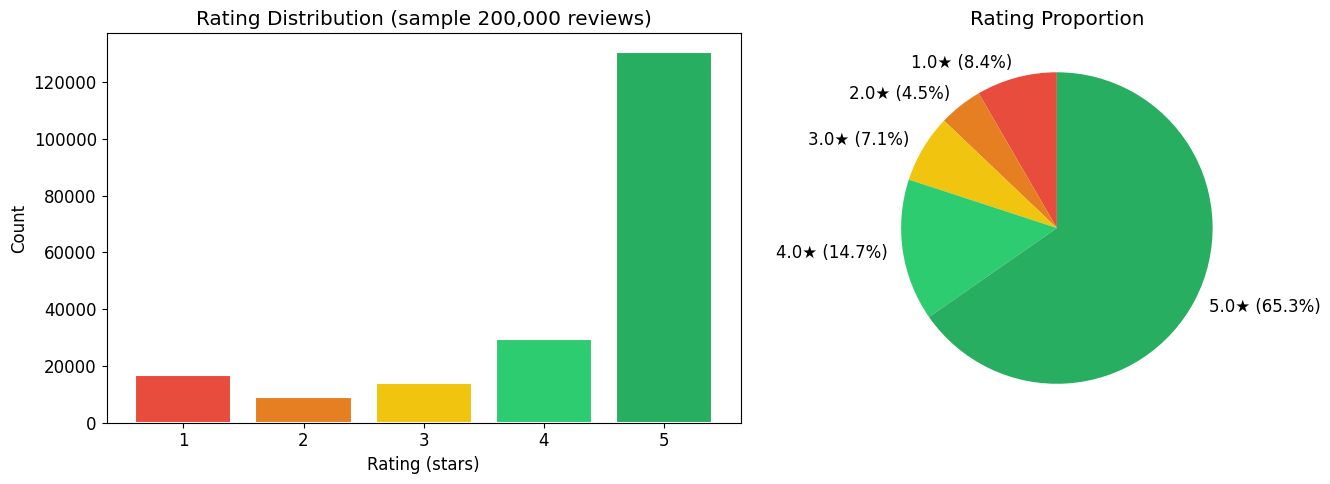

In [12]:
# ═══════════════════════════════════════════════════════════════
# CELL 8: Phân bố Rating (từ sample Cell 7)
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 12

total_in_sample = sum(rating_counter.values())

print("=" * 65)
print("PHÂN BỐ RATING (sample)")
print("=" * 65)
print(f"  {'Rating':<10} {'Count':>12} {'%':>8} {'Bar'}")
print(f"  {'-'*55}")

ratings_sorted = sorted(rating_counter.items())
for rating, count in ratings_sorted:
    pct = count / total_in_sample * 100
    bar = '█' * int(pct / 2)
    print(f"  {rating:<10} {count:>12,} {pct:>7.1f}% {bar}")

avg_rating = sum(r * c for r, c in rating_counter.items()) / total_in_sample
print(f"\n  📊 Rating trung bình: {avg_rating:.2f}")
print(f"  📊 Tổng sample: {total_in_sample:,}")

# Biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ratings = [r for r, _ in ratings_sorted]
counts = [c for _, c in ratings_sorted]
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
axes[0].bar(ratings, counts, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Rating (stars)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Rating Distribution (sample {total_in_sample:,} reviews)')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Pie chart
pcts = [c / total_in_sample * 100 for c in counts]
labels = [f'{r}★ ({p:.1f}%)' for r, p in zip(ratings, pcts)]
axes[1].pie(counts, labels=labels, colors=colors, startangle=90, autopct='')
axes[1].set_title('Rating Proportion')

plt.tight_layout()
plt.tight_layout()
plt.show()

## 7️⃣ Ước lượng Token Counts (§3.1)

**Tài liệu ghi:** `Review Tokens = 2.7B` | `Meta Tokens = 1.7B`

**Phương pháp:** Đếm tokens (whitespace split) trên sample → extrapolate cho toàn bộ dataset.

In [13]:
# ═══════════════════════════════════════════════════════════════
# CELL 10: Ước lượng Token Counts (§3.1)
# ═══════════════════════════════════════════════════════════════
TOKEN_SAMPLE = 50_000

# --- Review tokens ---
review_ds_tok = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Electronics",
    split="full", streaming=True, trust_remote_code=True
)

review_token_count = 0
review_text_fields = ['title', 'text']
count_r = 0

print(f"⏳ Đếm tokens trong {TOKEN_SAMPLE:,} review records...")
for record in review_ds_tok:
    for field in review_text_fields:
        text = record.get(field, '') or ''
        review_token_count += len(text.split())
    count_r += 1
    if count_r >= TOKEN_SAMPLE:
        break

avg_tokens_per_review = review_token_count / count_r
total_reviews_est = num_ratings_actual if isinstance(num_ratings_actual, int) else DOC_CLAIMS['num_ratings']
estimated_review_tokens = int(avg_tokens_per_review * total_reviews_est)

# --- Meta tokens ---
meta_ds_tok = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_meta_Electronics",
    split="full", streaming=True, trust_remote_code=True
)

meta_token_count = 0
meta_text_fields = ['title', 'features', 'description']
count_m = 0

print(f"⏳ Đếm tokens trong {TOKEN_SAMPLE:,} metadata records...")
for record in meta_ds_tok:
    for field in meta_text_fields:
        val = record.get(field, '') or ''
        if isinstance(val, list):
            text = ' '.join([str(v) for v in val])
        else:
            text = str(val)
        meta_token_count += len(text.split())
    count_m += 1
    if count_m >= TOKEN_SAMPLE:
        break

avg_tokens_per_meta = meta_token_count / count_m
total_items_est = num_items_actual if isinstance(num_items_actual, int) else DOC_CLAIMS['num_items']
estimated_meta_tokens = int(avg_tokens_per_meta * total_items_est)

print(f"\n{'='*70}")
print(f"§3.1 — ƯỚC LƯỢNG TOKEN COUNTS (sample {TOKEN_SAMPLE:,} records)")
print(f"{'='*70}")
print(f"  {'Chỉ số':<30} {'Tài liệu':>15} {'Ước lượng':>15} {'Tỷ lệ':>10}")
print(f"  {'-'*70}")
print(f"  {'Review Tokens':<30} {DOC_CLAIMS['review_tokens']:>15,} {estimated_review_tokens:>15,} {estimated_review_tokens/DOC_CLAIMS['review_tokens']*100:>9.1f}%")
print(f"  {'Meta Tokens':<30} {DOC_CLAIMS['meta_tokens']:>15,} {estimated_meta_tokens:>15,} {estimated_meta_tokens/DOC_CLAIMS['meta_tokens']*100:>9.1f}%")
print(f"\n  📊 Avg tokens/review:  {avg_tokens_per_review:.1f} (title + text)")
print(f"  📊 Avg tokens/meta:    {avg_tokens_per_meta:.1f} (title + features + description)")
print(f"\n  💡 Sai số do sampling — tăng TOKEN_SAMPLE để chính xác hơn")

⏳ Đếm tokens trong 50,000 review records...
⏳ Đếm tokens trong 50,000 metadata records...

§3.1 — ƯỚC LƯỢNG TOKEN COUNTS (sample 50,000 records)
  Chỉ số                                Tài liệu       Ước lượng      Tỷ lệ
  ----------------------------------------------------------------------
  Review Tokens                    2,700,000,000   3,198,849,008     118.5%
  Meta Tokens                      1,700,000,000     289,259,167      17.0%

  📊 Avg tokens/review:  72.9 (title + text)
  📊 Avg tokens/meta:    179.7 (title + features + description)

  💡 Sai số do sampling — tăng TOKEN_SAMPLE để chính xác hơn


## 6️⃣ Khảo sát verified_purchase, helpful_vote & độ dài text (§3.2)

**Tài liệu ghi:**
- `verified_purchase: Boolean` — đánh dấu mua hàng xác thực
- `helpful_vote: Integer` — số lượt vote hữu ích
- `text: String` — nội dung review

**Kiểm tra:** Tỷ lệ verified, phân bố helpful_vote, độ dài text từ sample.

⏳ Streaming 100,000 records để phân tích RQS signals...

§3.2 — KHẢO SÁT REVIEW FIELDS (sample 100,000 reviews)

📌 VERIFIED PURCHASE
   Verified:         78,983 (79.0%)
   Not verified:     21,017 (21.0%)
   → Đủ variance để phân tích: ✅ Có

👍 HELPFUL VOTE
   Min:           0
   Max:        6386
   Mean:       1.59
   Median:      0.0
   % = 0:  74.4%
   % ≥ 1:  25.6%
   % ≥ 5:  5.3%
   % ≥ 10: 2.6%

📝 REVIEW TEXT LENGTH
   Mean words:       68.3
   Median words:     34.0
   % empty:      0.0%
   % ≥ 10 words: 80.5%

📷 REVIEW IMAGES (review effort signal)
   Has images:    7,020 (7.0%)


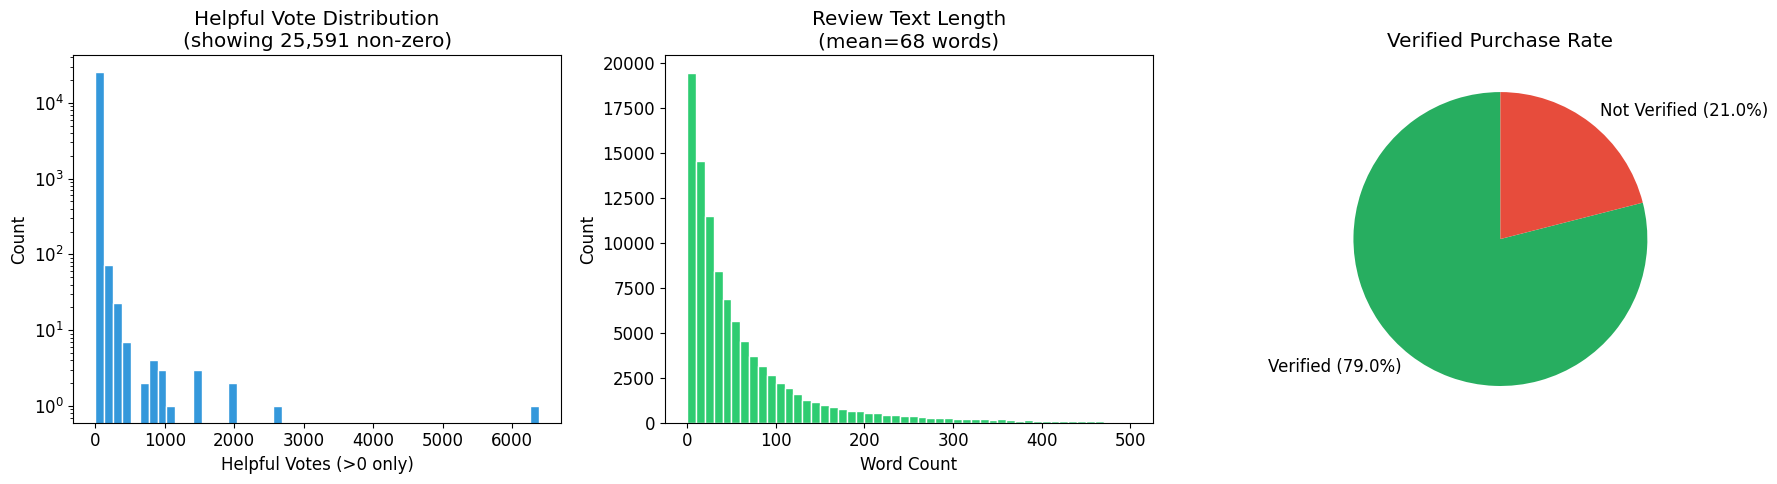

In [14]:
# ═══════════════════════════════════════════════════════════════
# CELL 8: Khảo sát verified_purchase, helpful_vote & text (§3.2)
# ═══════════════════════════════════════════════════════════════
RQS_SAMPLE = 100_000

review_ds_rqs = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Electronics",
    split="full", streaming=True, trust_remote_code=True
)

verified_count = 0
helpful_votes = []
has_images_count = 0
text_lengths = []
count_rqs = 0

print(f"⏳ Streaming {RQS_SAMPLE:,} records để phân tích RQS signals...")
for record in review_ds_rqs:
    # verified_purchase
    vp = record.get('verified_purchase', False)
    if vp:
        verified_count += 1
    
    # helpful_vote
    hv = record.get('helpful_vote', 0) or 0
    helpful_votes.append(hv)
    
    # images (review effort signal)
    imgs = record.get('images', []) or []
    if len(imgs) > 0:
        has_images_count += 1
    
    # text length
    text = record.get('text', '') or ''
    text_lengths.append(len(text.split()))
    
    count_rqs += 1
    if count_rqs >= RQS_SAMPLE:
        break

verified_rate = verified_count / count_rqs
helpful_arr = np.array(helpful_votes)
text_arr = np.array(text_lengths)

print(f"\n{'='*70}")
print(f"§3.2 — KHẢO SÁT REVIEW FIELDS (sample {RQS_SAMPLE:,} reviews)")
print(f"{'='*70}")

# Verified Purchase
print(f"\n📌 VERIFIED PURCHASE")
print(f"   Verified:     {verified_count:>10,} ({verified_rate*100:.1f}%)")
print(f"   Not verified: {count_rqs - verified_count:>10,} ({(1-verified_rate)*100:.1f}%)")
print(f"   → Đủ variance để phân tích: {'✅ Có' if 0.3 < verified_rate < 0.95 else '⚠️ Ít variance'}")

# Helpful Vote
print(f"\n👍 HELPFUL VOTE")
print(f"   Min:    {helpful_arr.min():>8}")
print(f"   Max:    {helpful_arr.max():>8}")
print(f"   Mean:   {helpful_arr.mean():>8.2f}")
print(f"   Median: {np.median(helpful_arr):>8.1f}")
print(f"   % = 0:  {(helpful_arr == 0).sum() / len(helpful_arr) * 100:.1f}%")
print(f"   % ≥ 1:  {(helpful_arr >= 1).sum() / len(helpful_arr) * 100:.1f}%")
print(f"   % ≥ 5:  {(helpful_arr >= 5).sum() / len(helpful_arr) * 100:.1f}%")
print(f"   % ≥ 10: {(helpful_arr >= 10).sum() / len(helpful_arr) * 100:.1f}%")

# Review Text
print(f"\n📝 REVIEW TEXT LENGTH")
print(f"   Mean words:   {text_arr.mean():>8.1f}")
print(f"   Median words: {np.median(text_arr):>8.1f}")
print(f"   % empty:      {(text_arr == 0).sum() / len(text_arr) * 100:.1f}%")
print(f"   % ≥ 10 words: {(text_arr >= 10).sum() / len(text_arr) * 100:.1f}%")

# Images (review effort)
print(f"\n📷 REVIEW IMAGES (review effort signal)")
print(f"   Has images: {has_images_count:>8,} ({has_images_count/count_rqs*100:.1f}%)")

# Biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Helpful vote distribution (log scale)
axes[0].hist(helpful_arr[helpful_arr > 0], bins=50, color='#3498db', edgecolor='white')
axes[0].set_xlabel('Helpful Votes (>0 only)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Helpful Vote Distribution\n(showing {(helpful_arr>0).sum():,} non-zero)')
axes[0].set_yscale('log')

# Text length distribution
axes[1].hist(text_arr[text_arr > 0], bins=50, color='#2ecc71', edgecolor='white', range=(0, 500))
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Review Text Length\n(mean={text_arr.mean():.0f} words)')

# Verified purchase pie
vp_data = [verified_count, count_rqs - verified_count]
axes[2].pie(vp_data, labels=[f'Verified ({verified_rate*100:.1f}%)', 
            f'Not Verified ({(1-verified_rate)*100:.1f}%)'],
            colors=['#27ae60', '#e74c3c'], startangle=90)
axes[2].set_title('Verified Purchase Rate')

plt.tight_layout()
plt.tight_layout()
plt.show()

## 7️⃣ Phân bố Price, Brand, Rating Number trong Metadata (§3.3)

**Tài liệu ghi:**
- `price: String/Float` — giá sản phẩm
- `rating_number: Integer` — tổng số reviews của sản phẩm
- `store: String` — tên store/brand bán sản phẩm

**Kiểm tra:** Phân bố price, rating_number, store/brand coverage từ metadata sample.

⏳ Streaming 100,000 metadata records...

§3.3 — METADATA FIELD ANALYSIS (sample 100,000 items, 196.7s)

💰 PRICE DISTRIBUTION
   Parseable prices:              41,824 / 100,000 (41.8%)
   Null/unparseable:              58,176 (58.2%)
   Min price:                $      0.01
   Max price:                $  12999.00
   Mean price:               $     87.52
   Median price:             $     20.89

   📊 Phân khúc giá:
      < $50:                      31,076 (74.3%)
      $50-$120:                    4,983 (11.9%)
      > $120:                      5,765 (13.8%)

📊 RATING NUMBER DISTRIBUTION
   Total with rating_number:    100,000
   Min:                               1
   Max:                         507,202
   Mean:                          450.6
   Median:                         20.0

   📊 Phân khúc số lượng review:
      < 50 reviews:                65,190 (65.2%)
      ≥ 50 reviews:                34,810 (34.8%)

🏪 STORE/BRAND DISTRIBUTION
   Items có store:               99,444 (99.

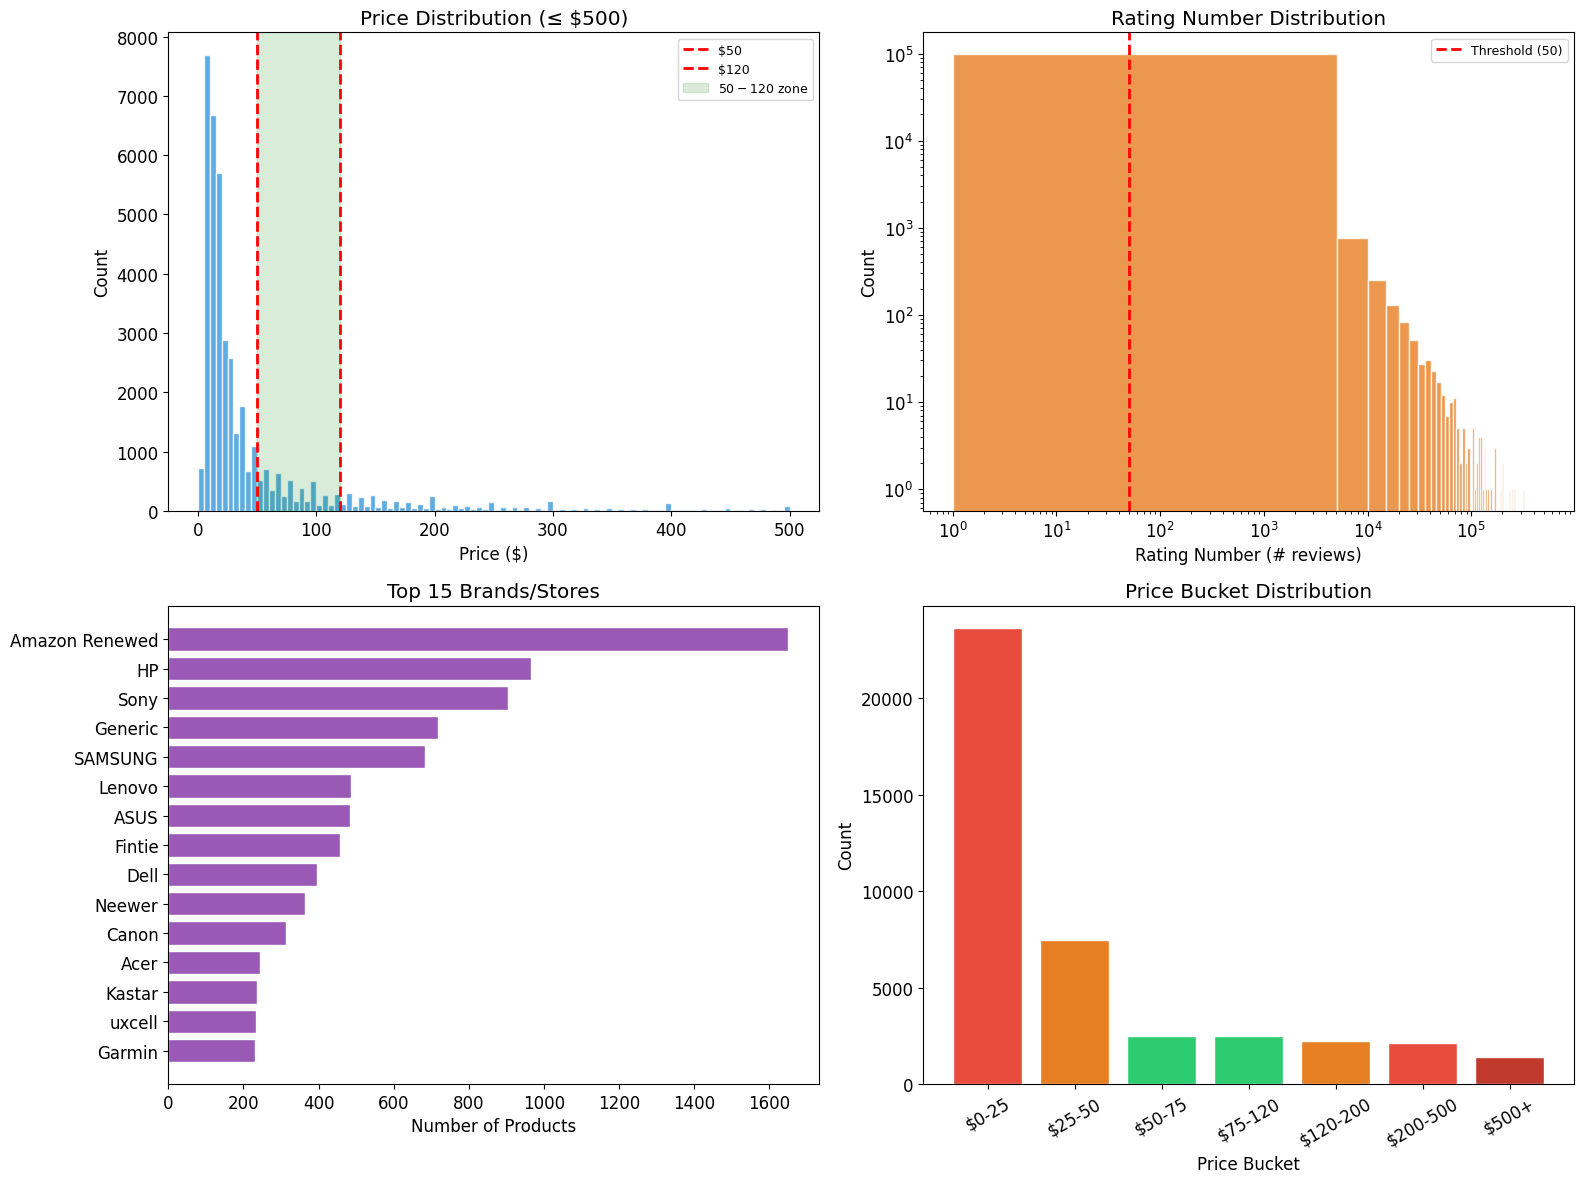

In [15]:
# ═══════════════════════════════════════════════════════════════
# CELL 9: Phân bố Price, Rating_Number, Store/Brand (§3.3)
# ═══════════════════════════════════════════════════════════════
import re

META_SAMPLE = 100_000

meta_ds_kb = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_meta_Electronics",
    split="full", streaming=True, trust_remote_code=True
)

prices = []
prices_raw = []         # giá trị price gốc (string)
rating_numbers = []
stores = []
categories_list = []
null_counts = defaultdict(int)
count_meta = 0

def parse_price(price_val):
    """Parse price string → float. Xử lý các format: '$29.99', '$10 - $50', None, ''"""
    if price_val is None or price_val == '' or price_val == 'None':
        return None
    s = str(price_val).strip()
    # Lấy giá đầu tiên nếu là range (e.g., "$10.99 - $29.99")
    match = re.search(r'\$?([\d,]+\.?\d*)', s)
    if match:
        try:
            return float(match.group(1).replace(',', ''))
        except ValueError:
            return None
    return None

print(f"⏳ Streaming {META_SAMPLE:,} metadata records...")
t0 = time.time()

for record in meta_ds_kb:
    # Price
    price_raw = record.get('price', None)
    prices_raw.append(price_raw)
    price_num = parse_price(price_raw)
    if price_num is not None and price_num > 0:
        prices.append(price_num)
    
    # Rating number
    rn = record.get('rating_number', None)
    if rn is not None:
        rating_numbers.append(rn)
    
    # Store (brand proxy)
    store = record.get('store', None)
    if store and str(store).strip() and store != 'None':
        stores.append(str(store).strip())
    else:
        null_counts['store'] += 1
    
    # Categories
    cats = record.get('categories', []) or []
    if cats:
        categories_list.extend(cats)
    
    # Null tracking
    for field in ['price', 'rating_number', 'store', 'categories', 'title', 'description', 'features']:
        val = record.get(field, None)
        if val is None or val == '' or val == [] or val == 'None':
            null_counts[field] += 1
    
    count_meta += 1
    if count_meta >= META_SAMPLE:
        break

elapsed = time.time() - t0

price_arr = np.array(prices)
rn_arr = np.array(rating_numbers)
store_counter = Counter(stores)

print(f"\n{'='*75}")
print(f"§3.3 — METADATA FIELD ANALYSIS (sample {META_SAMPLE:,} items, {elapsed:.1f}s)")
print(f"{'='*75}")

# ── PRICE ANALYSIS ──
print(f"\n💰 PRICE DISTRIBUTION")
print(f"   Parseable prices:          {len(prices):>10,} / {count_meta:,} ({len(prices)/count_meta*100:.1f}%)")
print(f"   Null/unparseable:          {count_meta - len(prices):>10,} ({(count_meta-len(prices))/count_meta*100:.1f}%)")
if len(price_arr) > 0:
    print(f"   Min price:                ${price_arr.min():>10.2f}")
    print(f"   Max price:                ${price_arr.max():>10.2f}")
    print(f"   Mean price:               ${price_arr.mean():>10.2f}")
    print(f"   Median price:             ${np.median(price_arr):>10.2f}")
    
    # Phân khúc giá
    in_range = ((price_arr >= 50) & (price_arr <= 120)).sum()
    below_50 = (price_arr < 50).sum()
    above_120 = (price_arr > 120).sum()
    print(f"\n   📊 Phân khúc giá:")
    print(f"      < $50:                  {below_50:>10,} ({below_50/len(price_arr)*100:.1f}%)")
    print(f"      $50-$120:               {in_range:>10,} ({in_range/len(price_arr)*100:.1f}%)")
    print(f"      > $120:                 {above_120:>10,} ({above_120/len(price_arr)*100:.1f}%)")

# ── RATING NUMBER ANALYSIS ──
print(f"\n📊 RATING NUMBER DISTRIBUTION")
print(f"   Total with rating_number: {len(rn_arr):>10,}")
if len(rn_arr) > 0:
    print(f"   Min:                      {rn_arr.min():>10,}")
    print(f"   Max:                      {rn_arr.max():>10,}")
    print(f"   Mean:                     {rn_arr.mean():>10.1f}")
    print(f"   Median:                   {np.median(rn_arr):>10.1f}")
    
    gte50 = (rn_arr >= 50).sum()
    lt50 = (rn_arr < 50).sum()
    print(f"\n   📊 Phân khúc số lượng review:")
    print(f"      < 50 reviews:            {lt50:>10,} ({lt50/len(rn_arr)*100:.1f}%)")
    print(f"      ≥ 50 reviews:            {gte50:>10,} ({gte50/len(rn_arr)*100:.1f}%)")

# ── STORE/BRAND ANALYSIS ──
print(f"\n🏪 STORE/BRAND DISTRIBUTION")
print(f"   Items có store:           {len(stores):>10,} ({len(stores)/count_meta*100:.1f}%)")
print(f"   Null store:               {null_counts['store']:>10,} ({null_counts['store']/count_meta*100:.1f}%)")
print(f"   Unique stores/brands:     {len(store_counter):>10,}")
print(f"\n   Top 20 stores/brands:")
for rank, (store, cnt) in enumerate(store_counter.most_common(20), 1):
    print(f"      {rank:>3}. {store:<35} {cnt:>6,} ({cnt/len(stores)*100:.2f}%)")

# ── NULL RATE per field ──
print(f"\n⚠️ NULL RATES (Metadata fields, sample {count_meta:,}):")
for field, cnt in sorted(null_counts.items(), key=lambda x: -x[1]):
    print(f"   {field:<20} {cnt:>8,} ({cnt/count_meta*100:.1f}%)")

# ── Biểu đồ ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Price distribution
if len(price_arr) > 0:
    axes[0, 0].hist(price_arr[price_arr <= 500], bins=100, color='#3498db', edgecolor='white', alpha=0.8)
    axes[0, 0].axvline(x=50, color='red', linestyle='--', linewidth=2, label='$50')
    axes[0, 0].axvline(x=120, color='red', linestyle='--', linewidth=2, label='$120')
    axes[0, 0].axvspan(50, 120, alpha=0.15, color='green', label='$50-$120 zone')
    axes[0, 0].set_xlabel('Price ($)')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Price Distribution (≤ $500)')
    axes[0, 0].legend(fontsize=9)

# Rating number distribution (log scale)
if len(rn_arr) > 0:
    axes[0, 1].hist(rn_arr[rn_arr > 0], bins=100, color='#e67e22', edgecolor='white', alpha=0.8)
    axes[0, 1].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Threshold (50)')
    axes[0, 1].set_xlabel('Rating Number (# reviews)')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Rating Number Distribution')
    axes[0, 1].set_xscale('log')
    axes[0, 1].set_yscale('log')
    axes[0, 1].legend(fontsize=9)

# Top 15 brands bar
top15 = store_counter.most_common(15)
if top15:
    brands = [b for b, _ in top15]
    bcounts = [c for _, c in top15]
    axes[1, 0].barh(brands[::-1], bcounts[::-1], color='#9b59b6', edgecolor='white')
    axes[1, 0].set_xlabel('Number of Products')
    axes[1, 0].set_title('Top 15 Brands/Stores')

# Price bucket distribution (for popularity-within-price-bucket fallback)
if len(price_arr) > 0:
    buckets = ['$0-25', '$25-50', '$50-75', '$75-120', '$120-200', '$200-500', '$500+']
    bucket_edges = [0, 25, 50, 75, 120, 200, 500, np.inf]
    bucket_counts = []
    for i in range(len(bucket_edges)-1):
        cnt = ((price_arr >= bucket_edges[i]) & (price_arr < bucket_edges[i+1])).sum()
        bucket_counts.append(cnt)
    colors_bucket = ['#e74c3c', '#e67e22', '#2ecc71', '#2ecc71', '#e67e22', '#e74c3c', '#c0392b']
    axes[1, 1].bar(buckets, bucket_counts, color=colors_bucket, edgecolor='white')
    axes[1, 1].set_xlabel('Price Bucket')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_title('Price Bucket Distribution')
    axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.tight_layout()
plt.show()

## 8️⃣ Phân bố Reviews theo Thời gian (§3.1)

**Tài liệu ghi:** Khoảng thời gian: May 1996 → Sep 2023

**Kiểm tra:** Phân bố reviews theo năm, trend rating trung bình theo năm, monthly volume.

⏳ Streaming 300,000 records để phân tích temporal trend...

TẦNG 2 — TEMPORAL TREND ANALYSIS (sample 300,000 records, 34.5s)
§3.1 — TEMPORAL ANALYSIS (sample 300,000 records, 34.5s)

📅 REVIEWS THEO NĂM:
   Năm        #Reviews   Avg Rating   Std Rating    Stability
   ------------------------------------------------------------
   1998              1        5.000        0.000        1.000
   1999              1        2.000        0.000        1.000
   2000             14        4.429        1.050        0.488
   2001             20        4.250        1.178        0.459
   2002             41        3.854        1.441        0.410
   2003             49        3.918        1.322        0.431
   2004             96        3.635        1.562        0.390
   2005            172        3.872        1.413        0.415
   2006            256        3.902        1.442        0.409
   2007            598        3.990        1.315        0.432
   2008            795        4.000        1.314   

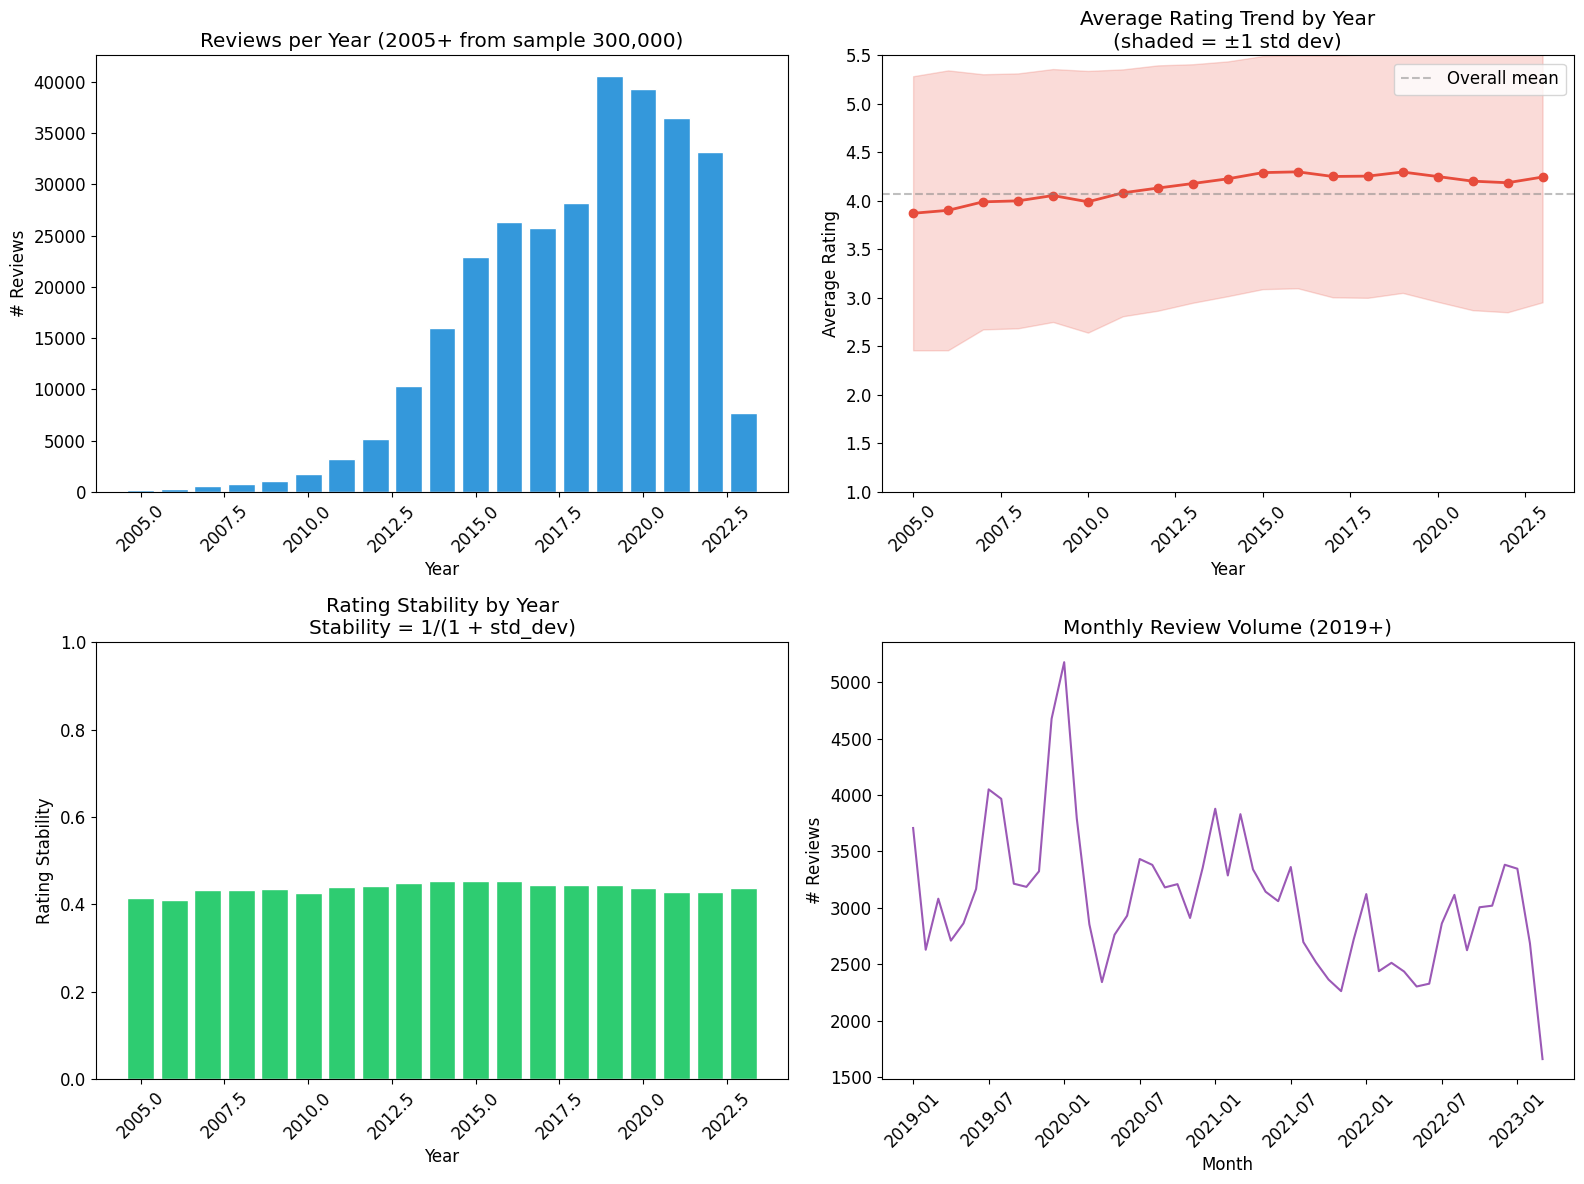

In [18]:
# ═══════════════════════════════════════════════════════════════
# CELL 10: Phân bố Reviews theo năm + Rating trend
# ═══════════════════════════════════════════════════════════════
TEMPORAL_SAMPLE = 300_000

review_ds_temporal = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Electronics",
    split="full", streaming=True, trust_remote_code=True
)

year_rating = defaultdict(list)    # {year: [ratings]}
year_count = Counter()              # {year: count}
month_count = Counter()             # {year-month: count}
count_temp = 0

print(f"⏳ Streaming {TEMPORAL_SAMPLE:,} records để phân tích temporal trend...")
t0 = time.time()

for record in review_ds_temporal:
    ts = record.get('timestamp', 0)
    rating = record.get('rating', 0)

    # Chuẩn hoá timestamp an toàn (seconds / milliseconds / microseconds)
    # và bỏ qua các giá trị không hợp lệ để tránh OSError: [Errno 22]
    dt = None
    try:
        ts_num = float(ts)
    except (TypeError, ValueError):
        ts_num = 0

    if ts_num > 0:
        if ts_num > 1e14:        # microseconds
            ts_sec = ts_num / 1_000_000
        elif ts_num > 1e11:      # milliseconds
            ts_sec = ts_num / 1_000
        else:                    # seconds
            ts_sec = ts_num

        try:
            dt = datetime.fromtimestamp(ts_sec)
        except (OSError, OverflowError, ValueError):
            dt = None

    if dt is not None:
        year = dt.year
        ym = f"{dt.year}-{dt.month:02d}"

        year_rating[year].append(rating)
        year_count[year] += 1
        month_count[ym] += 1

    count_temp += 1
    if count_temp >= TEMPORAL_SAMPLE:
        break

elapsed = time.time() - t0

# Tính stats theo năm
years_sorted = sorted(year_rating.keys())
year_stats = []
for y in years_sorted:
    ratings = year_rating[y]
    std_val = np.std(ratings)
    year_stats.append({
        'year': y,
        'count': len(ratings),
        'mean_rating': np.mean(ratings),
        'std_rating': std_val,
        'stability': 1 / (1 + std_val),
    })

stats_df = pd.DataFrame(year_stats)

print(f"\n{'='*80}")
print(f"TẦNG 2 — TEMPORAL TREND ANALYSIS (sample {TEMPORAL_SAMPLE:,} records, {elapsed:.1f}s)")
print(f"§3.1 — TEMPORAL ANALYSIS (sample {TEMPORAL_SAMPLE:,} records, {elapsed:.1f}s)")

print(f"\n📅 REVIEWS THEO NĂM:")
print(f"   {'Năm':<8} {'#Reviews':>10} {'Avg Rating':>12} {'Std Rating':>12} {'Stability':>12}")
print(f"   {'-'*60}")
for _, row in stats_df.iterrows():
    print(f"   {int(row['year']):<8} {int(row['count']):>10,} {row['mean_rating']:>12.3f} {row['std_rating']:>12.3f} {row['stability']:>12.3f}")

# Phân tích recency (cho Weighted_Rating)
# Phân tích theo giai đoạn
latest_year = max(years_sorted)
recent_12m = sum(1 for ym, c in month_count.items() if ym >= f"{latest_year-1}-{datetime.now().month:02d}")
print(f"\n📊 TỔNG HỢP THEO GIAI ĐOẠN:")
print(f"   Latest year in data:       {latest_year}")
print(f"   Reviews in latest year:    {year_count.get(latest_year, 0):,} ({year_count.get(latest_year, 0)/count_temp*100:.1f}%)")
print(f"   Reviews 2019-2023:         {sum(year_count[y] for y in range(2019, 2024) if y in year_count):,}")
print(f"   Reviews trước 2019:        {sum(year_count[y] for y in year_count if y < 2019):,}")
print(f"   Reviews 12 tháng gần nhất: {recent_12m:,}")

# ── Biểu đồ ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Reviews theo năm
focus_years = [y for y in years_sorted if y >= 2005]
focus_counts = [year_count[y] for y in focus_years]
axes[0, 0].bar(focus_years, focus_counts, color='#3498db', edgecolor='white')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('# Reviews')
axes[0, 0].set_title(f'Reviews per Year (2005+ from sample {TEMPORAL_SAMPLE:,})')
axes[0, 0].tick_params(axis='x', rotation=45)

# Average rating theo năm
focus_stats = stats_df[stats_df['year'] >= 2005]
axes[0, 1].plot(focus_stats['year'], focus_stats['mean_rating'], 'o-',
                color='#e74c3c', linewidth=2, markersize=6)
axes[0, 1].fill_between(focus_stats['year'],
                        focus_stats['mean_rating'] - focus_stats['std_rating'],
                        focus_stats['mean_rating'] + focus_stats['std_rating'],
                        alpha=0.2, color='#e74c3c')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Average Rating')
axes[0, 1].set_title('Average Rating Trend by Year\n(shaded = ±1 std dev)')
axes[0, 1].set_ylim(1, 5.5)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].axhline(y=stats_df['mean_rating'].mean(), color='gray', linestyle='--', alpha=0.5, label='Overall mean')
axes[0, 1].legend()

# Rating Stability theo năm
axes[1, 0].bar(focus_stats['year'], focus_stats['stability'], color='#2ecc71', edgecolor='white')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Rating Stability')
axes[1, 0].set_title('Rating Stability by Year\nStability = 1/(1 + std_dev)')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=45)

# Monthly trend (recent years)
recent_months = {k: v for k, v in month_count.items() if k >= '2019-01'}
if recent_months:
    months_sorted = sorted(recent_months.keys())
    month_vals = [recent_months[m] for m in months_sorted]
    axes[1, 1].plot(range(len(months_sorted)), month_vals, '-', color='#9b59b6', linewidth=1.5)
    tick_positions = list(range(0, len(months_sorted), 6))
    tick_labels = [months_sorted[i] for i in tick_positions]
    axes[1, 1].set_xticks(tick_positions)
    axes[1, 1].set_xticklabels(tick_labels, rotation=45)
    axes[1, 1].set_xlabel('Month')
    axes[1, 1].set_ylabel('# Reviews')
    axes[1, 1].set_title('Monthly Review Volume (2019+)')
else:
    axes[1, 1].set_title('No monthly data from 2019+')
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 9️⃣ Đánh giá Chất lượng Dữ liệu — Null Rates, Duplicates, Value Ranges

**Mục đích:** Đánh giá chất lượng dữ liệu thô, xác định các vấn đề cần xử lý.

**Các kiểm tra:**
1. Null/empty rate per field (Review)
2. Duplicate detection (duplicate user_id + parent_asin pairs)
3. Value range validation (rating [1-5], timestamp range)
4. Text quality (empty text, very short text)

In [19]:
# ═══════════════════════════════════════════════════════════════
# CELL 11: Data Quality Assessment — Reviews
# ═══════════════════════════════════════════════════════════════
QUALITY_SAMPLE = 200_000

review_ds_quality = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Electronics",
    split="full", streaming=True, trust_remote_code=True
)

# Review quality tracking
review_null_counts = defaultdict(int)
review_anomalies = defaultdict(int)
duplicate_pairs = set()
duplicate_count = 0
rating_values = Counter()
total_quality = 0

REVIEW_FIELDS = ['rating', 'title', 'text', 'images', 'asin', 
                 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

print(f"⏳ Data Quality scan: {QUALITY_SAMPLE:,} review records...")
t0 = time.time()

for record in review_ds_quality:
    # Null check per field
    for field in REVIEW_FIELDS:
        val = record.get(field, None)
        if val is None or val == '' or val == []:
            review_null_counts[field] += 1
    
    # Rating range check
    rating = record.get('rating', None)
    if rating is not None:
        rating_values[rating] += 1
        if rating < 1 or rating > 5:
            review_anomalies['rating_out_of_range'] += 1
    
    # Timestamp validation
    ts = record.get('timestamp', 0)
    if ts <= 0:
        review_anomalies['invalid_timestamp'] += 1
    else:
        ts_sec = ts / 1000 if ts > 1e12 else ts
        if ts_sec < 820454400:  # before 1996
            review_anomalies['timestamp_too_early'] += 1
        if ts_sec > 1696118400:  # after Oct 2023
            review_anomalies['timestamp_too_late'] += 1
    
    # Duplicate pair check (user_id + parent_asin)
    uid = record.get('user_id', '')
    pasin = record.get('parent_asin', '')
    pair = (uid, pasin)
    if pair in duplicate_pairs:
        duplicate_count += 1
    else:
        duplicate_pairs.add(pair)
    
    # Text quality
    text = record.get('text', '') or ''
    if len(text.strip()) == 0:
        review_anomalies['empty_text'] += 1
    elif len(text.split()) < 3:
        review_anomalies['very_short_text'] += 1
    
    # helpful_vote negative check
    hv = record.get('helpful_vote', 0)
    if hv is not None and hv < 0:
        review_anomalies['negative_helpful_vote'] += 1
    
    total_quality += 1
    if total_quality >= QUALITY_SAMPLE:
        break

elapsed = time.time() - t0

print(f"\n{'='*75}")
print(f"DATA QUALITY — REVIEW FILE (sample {QUALITY_SAMPLE:,} records, {elapsed:.1f}s)")
print(f"{'='*75}")

# Null rates
print(f"\n📋 NULL/EMPTY RATES PER FIELD:")
print(f"   {'Field':<22} {'Null/Empty':>10} {'Rate':>8} {'Status'}")
print(f"   {'-'*55}")
for field in REVIEW_FIELDS:
    cnt = review_null_counts.get(field, 0)
    rate = cnt / total_quality * 100
    status = '✅ OK' if rate < 1 else ('⚠️ Low' if rate < 10 else '❌ High')
    print(f"   {field:<22} {cnt:>10,} {rate:>7.2f}% {status}")

# Anomalies
print(f"\n🔍 ANOMALIES:")
print(f"   {'Check':<30} {'Count':>10} {'Rate':>8}")
print(f"   {'-'*50}")
for check, cnt in sorted(review_anomalies.items(), key=lambda x: -x[1]):
    rate = cnt / total_quality * 100
    print(f"   {check:<30} {cnt:>10,} {rate:>7.2f}%")

# Duplicates
print(f"\n🔄 DUPLICATE PAIRS (user_id + parent_asin):")
print(f"   Total records:             {total_quality:>10,}")
print(f"   Unique pairs:              {len(duplicate_pairs):>10,}")
print(f"   Duplicate records:         {duplicate_count:>10,} ({duplicate_count/total_quality*100:.2f}%)")
print(f"   → Cần xử lý duplicates ở Silver layer: {'✅ Ít' if duplicate_count/total_quality < 0.05 else '⚠️ Cần dedup'}")

# Rating value check
print(f"\n⭐ RATING VALUES (phải là 1.0-5.0):")
for r in sorted(rating_values.keys()):
    valid = '✅' if 1 <= r <= 5 else '❌'
    print(f"   {r:>5} → {rating_values[r]:>10,} ({rating_values[r]/total_quality*100:.1f}%) {valid}")

# Quality verdict
total_null = sum(review_null_counts.values())
total_anomaly = sum(review_anomalies.values())
print(f"\n{'='*75}")
print(f"📊 REVIEW DATA QUALITY VERDICT:")
print(f"   Total null/empty fields:     {total_null:>10,} ({total_null/(total_quality*len(REVIEW_FIELDS))*100:.2f}% of all cells)")
print(f"   Total anomalies:             {total_anomaly:>10,}")
print(f"   Duplicate rate:              {duplicate_count/total_quality*100:.2f}%")
quality_score = 100 - (total_null/(total_quality*len(REVIEW_FIELDS))*100) - (total_anomaly/total_quality*100)
print(f"   Overall Quality Score:       {quality_score:.1f}/100")
print(f"   → Đủ data cho Bronze ingestion: {'✅ Có' if quality_score > 85 else '⚠️ Cần data cleaning trước khi sử dụng'}")

⏳ Data Quality scan: 200,000 review records...

DATA QUALITY — REVIEW FILE (sample 200,000 records, 25.3s)

📋 NULL/EMPTY RATES PER FIELD:
   Field                  Null/Empty     Rate Status
   -------------------------------------------------------
   rating                          0    0.00% ✅ OK
   title                           0    0.00% ✅ OK
   text                            2    0.00% ✅ OK
   images                    189,067   94.53% ❌ High
   asin                            0    0.00% ✅ OK
   parent_asin                     0    0.00% ✅ OK
   user_id                         0    0.00% ✅ OK
   timestamp                       0    0.00% ✅ OK
   helpful_vote                    0    0.00% ✅ OK
   verified_purchase               0    0.00% ✅ OK

🔍 ANOMALIES:
   Check                               Count     Rate
   --------------------------------------------------
   very_short_text                    11,632    5.82%
   empty_text                             46    0.02%
   times